# 01 — Exploring the dataset

The ingested dataset behind everything: four seasons of ESPN games and
play-by-play, joined to every Kalshi NBA market the public API still serves
(2026 playoffs — see the data-retention note in the README). Regenerate it with
`engine ingest all`.

In [1]:
%config InlineBackend.figure_format = "retina"
import matplotlib.pyplot as plt
import numpy as np

from engine.data.store import Store

store = Store("sqlite:///../data/engine.db")

In [2]:
counts = store.counts()
counts

{'games': 5303,
 'game_snapshots': 2447012,
 'markets': 84,
 'market_candles': 126262}

## Games per season, and how often the home team wins

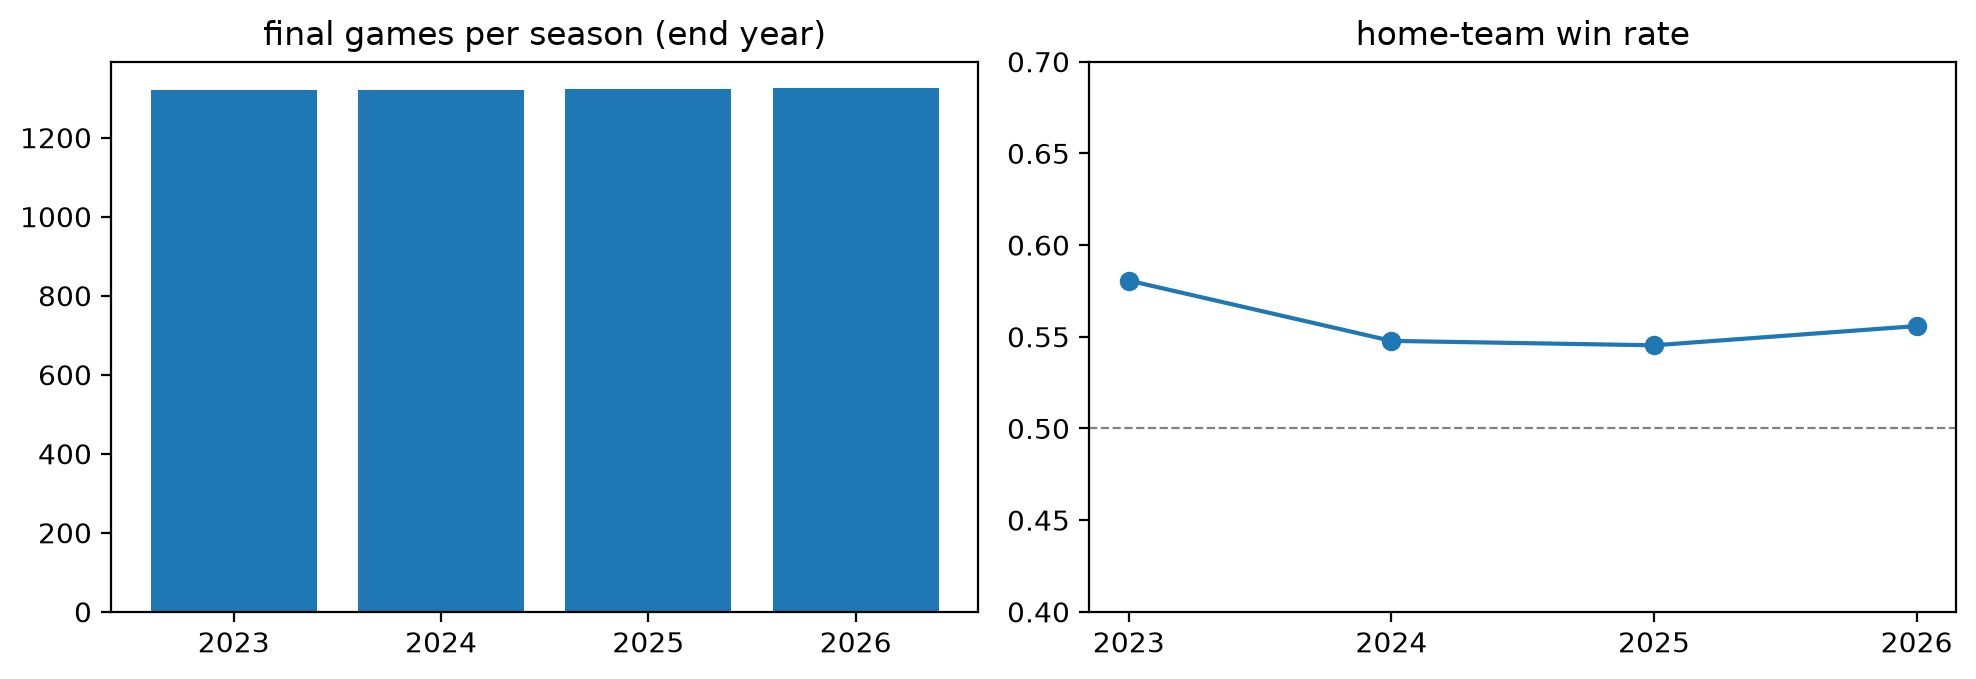

In [3]:
from collections import Counter

from engine.features.pregame import season_of
from engine.data.models import GameStatus

finals = [g for g in store.games(statuses=[GameStatus.FINAL]) if g.home_score != g.away_score]
by_season = Counter(season_of(g.start_time) for g in finals)
home_rate = {
    s: np.mean([g.home_won for g in finals if season_of(g.start_time) == s])
    for s in sorted(by_season)
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.bar([str(s) for s in sorted(by_season)], [by_season[s] for s in sorted(by_season)])
ax1.set_title("final games per season (end year)")
ax2.plot(list(map(str, home_rate)), list(home_rate.values()), marker="o")
ax2.axhline(0.5, linestyle="--", color="gray", linewidth=0.8)
ax2.set_ylim(0.4, 0.7)
ax2.set_title("home-team win rate")
fig.tight_layout()

## The market side: what Kalshi still serves

Every settled market, its volume, and the pre-tipoff overround (raw implied
probabilities summing above 1). Tight overrounds are the first sign this market
is not easy money.

84 markets, 42 games with a two-sided pre-tip quote
mean overround at tipoff: 0.0017
median market volume: 16,325,921 contracts


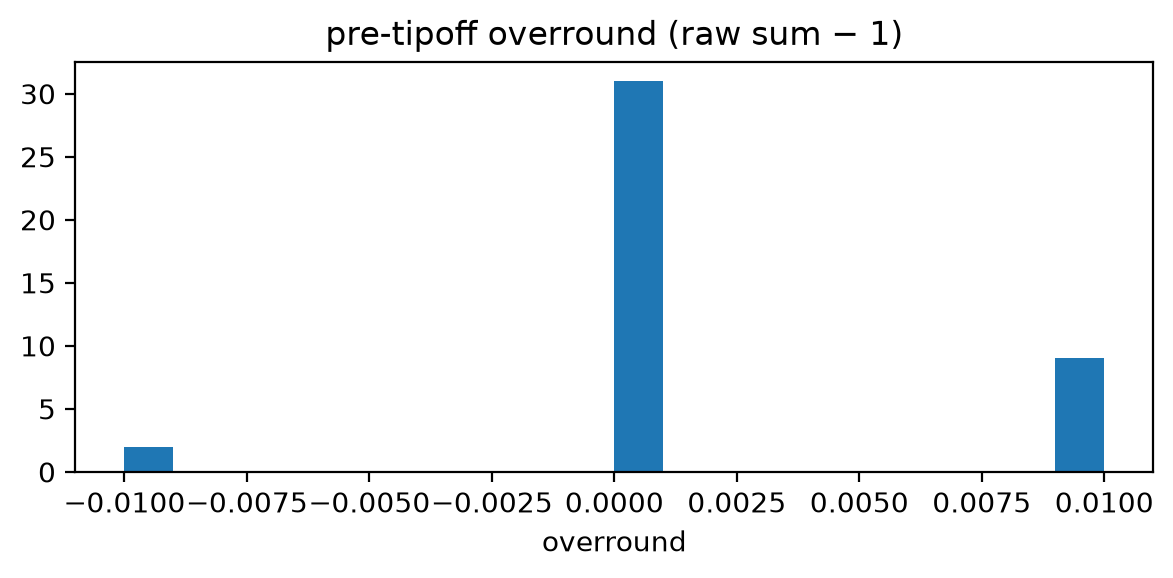

In [4]:
from engine.models.market_baseline import market_home_probability

markets = store.markets(with_game_only=True)
games = {g.game_id: g for g in store.games()}
overrounds, volumes = [], []
for info in markets:
    game = games[info.game_id]
    if info.yes_team != game.home_team:
        continue  # one row per game
    quote = market_home_probability(
        store, game_id=info.game_id, home_team=game.home_team, at=game.start_time
    )
    if quote is not None:
        overrounds.append(quote.overround)
    volumes.append(info.volume)

print(f"{len(markets)} markets, {len(overrounds)} games with a two-sided pre-tip quote")
print(f"mean overround at tipoff: {np.mean(overrounds):.4f}")
print(f"median market volume: {np.median(volumes):,.0f} contracts")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(overrounds, bins=20)
ax.set_title("pre-tipoff overround (raw sum − 1)")
ax.set_xlabel("overround")
fig.tight_layout()

## Price path of one market

One-minute candles for a Finals market, pre-game through settlement — the raw
material of the in-game comparison.

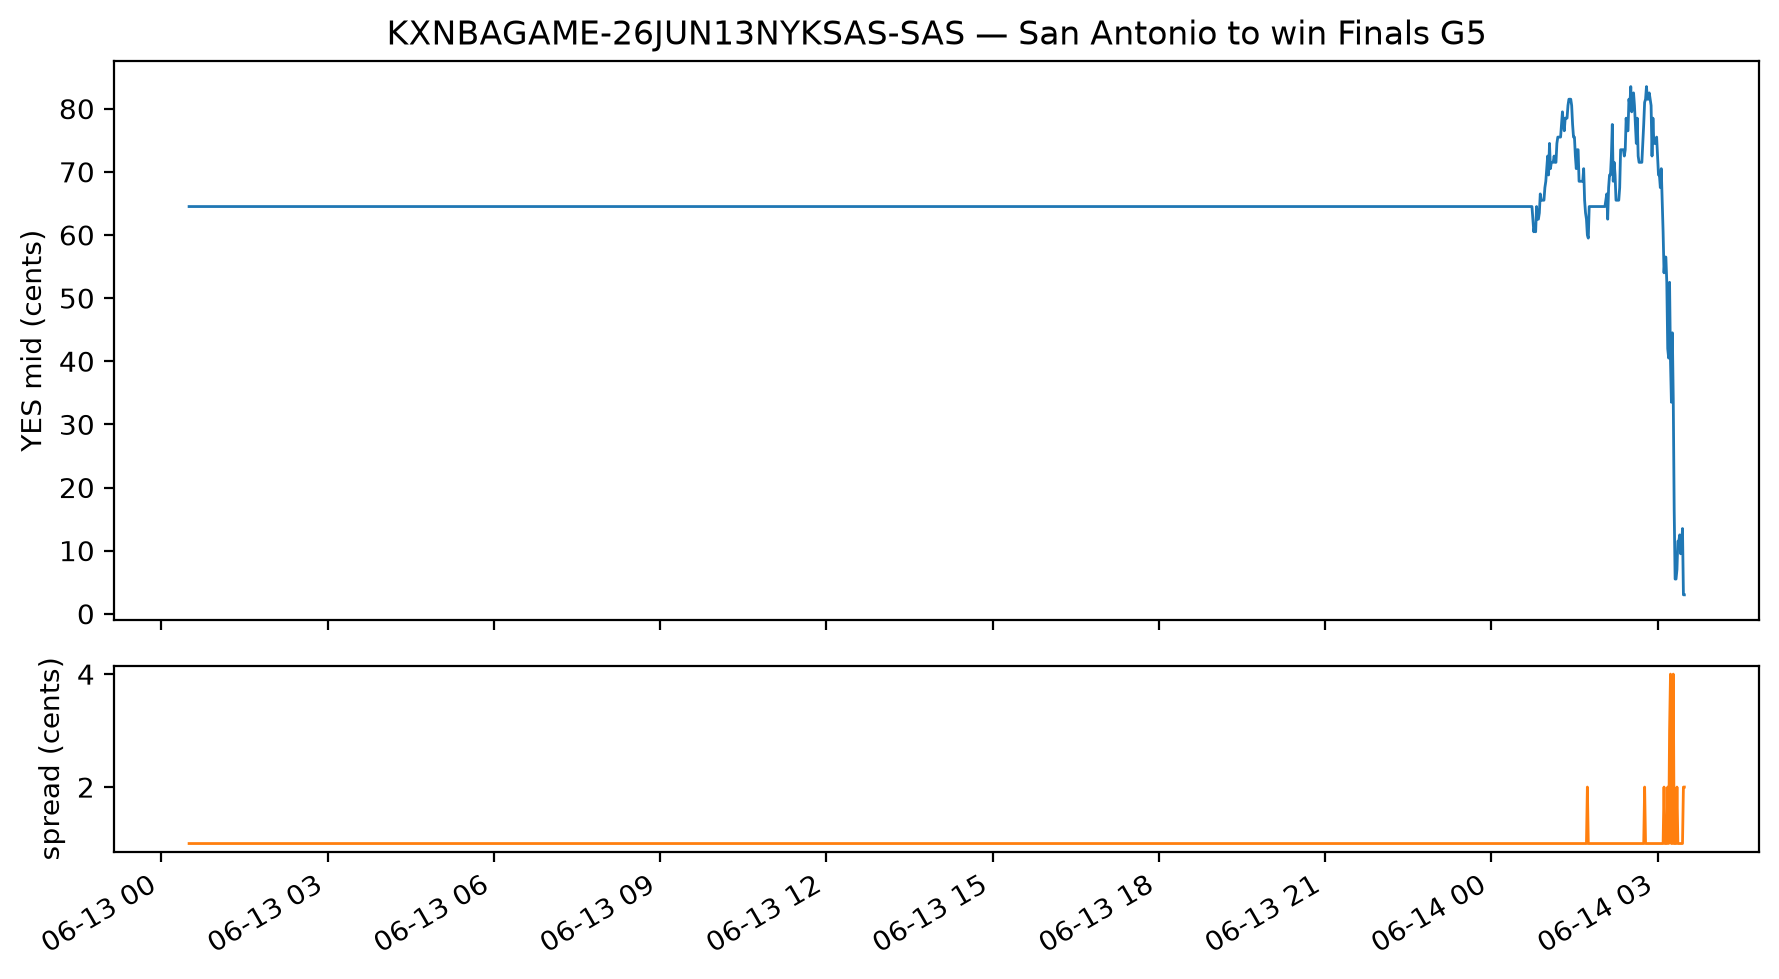

In [5]:
candles = store.candles("KXNBAGAME-26JUN13NYKSAS-SAS")
two_sided = [c for c in candles if c.yes_bid_close is not None and c.yes_ask_close is not None]
times = [c.end_time for c in two_sided]
mid = [(c.yes_bid_close + c.yes_ask_close) / 2 for c in two_sided]
spread = [c.yes_ask_close - c.yes_bid_close for c in two_sided]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True, height_ratios=[3, 1])
ax1.plot(times, mid, linewidth=1)
ax1.set_ylabel("YES mid (cents)")
ax1.set_title("KXNBAGAME-26JUN13NYKSAS-SAS — San Antonio to win Finals G5")
ax2.plot(times, spread, linewidth=1, color="tab:orange")
ax2.set_ylabel("spread (cents)")
fig.autofmt_xdate()
fig.tight_layout()